# Part 1 (Continued) — Multi-Face Handling + Classifier + Evaluation

Run this **after** your face extraction notebook. Before starting, make sure your Google Drive contains:
- `train_faces_processed.zip`, `dev_faces.zip`, `test_faces.zip` (from your extraction notebook)
- `train_ende.zip`, `dev.zip`, `test.zip` (original dataset — needed for multi-face re-extraction)
- `sentiment_train.txt`, `sentiment_dev.txt`, `sentiment_test.txt`

**Run cells in order from top to bottom.**

In [1]:
# CELL 1 — Mount Drive and install libraries
from google.colab import drive
drive.mount('/content/drive')

!pip install -q facenet-pytorch scikit-learn

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [1]:
# CELL 2 — Unzip original dataset folders onto Colab disk
# Colab wipes disk between sessions, so we always unzip from Drive
import os

if not os.path.exists('/content/dataset/train_ende'):
    print('Unzipping train...')
    os.system('unzip -q "/content/drive/MyDrive/AML/train_ende.zip" -d /content/dataset/')

if not os.path.exists('/content/dataset/dev'):
    print('Unzipping dev...')
    os.system('unzip -q "/content/drive/MyDrive/AML/dev.zip" -d /content/dataset/')

if not os.path.exists('/content/dataset/test'):
    print('Unzipping test...')
    os.system('unzip -q "/content/drive/MyDrive/AML/test.zip" -d /content/dataset/')

print('Done:', os.listdir('/content/dataset/'))

Done: ['dev', 'test', 'train_ende']


In [3]:
pip install --upgrade --force-reinstall "Pillow<10"

  Using cached Pillow-9.5.0-cp312-cp312-linux_x86_64.whl
  Attempting uninstall: Pillow
    Found existing installation: pillow 10.2.0
    Uninstalling pillow-10.2.0:
      Successfully uninstalled pillow-10.2.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
facenet-pytorch 2.6.0 requires Pillow<10.3.0,>=10.2.0, but you have pillow 9.5.0 which is incompatible.
scikit-image 0.25.2 requires pillow>=10.1, but you have pillow 9.5.0 which is incompatible.


In [2]:
# CELL 3 — All imports and global config
import os, json
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from facenet_pytorch import MTCNN
from PIL import Image
from tqdm import tqdm
from collections import Counter
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    f1_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
)
import warnings
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

LABEL_MAP   = {0: 'Neutral', 1: 'Negative', 2: 'Positive'}
NUM_CLASSES = 3

# --- Paths: change these if your Drive filenames are different ---
LABEL_TRAIN = '/content/drive/MyDrive/AML/sentiment_train.txt'
LABEL_DEV   = '/content/drive/MyDrive/AML/sentiment_dev.txt'
LABEL_TEST  = '/content/drive/MyDrive/AML/sentiment_test.txt'

ORIG_TRAIN  = '/content/dataset/train_ende'
ORIG_DEV    = '/content/dataset/dev'
ORIG_TEST   = '/content/dataset/test'

MULTI_TRAIN = '/content/multi_faces/train'
MULTI_DEV   = '/content/multi_faces/dev'
MULTI_TEST  = '/content/multi_faces/test'

BEST_MODEL  = '/content/drive/MyDrive/best_face_model.pth'

Device: cuda


In [3]:
# CELL 4 — Multi-face extraction (keep_all=True)
#
# Your original MTCNN used select_largest=True → only kept the biggest face.
# This cell re-runs MTCNN on the ORIGINAL images with keep_all=True so every
# detected face gets its own crop file:
#   42_face0.jpg, 42_face1.jpg, 42_face2.jpg  ...
# A JSON map records which crops belong to which original image.
# Images with zero faces fall back to the resized original (same as before).
#
# NOTE: This takes ~10-20 min on a T4 GPU for the full MSCTD train set.
# The result is saved to Drive so you only ever need to run it once.

mtcnn_multi = MTCNN(
    image_size=224,
    margin=20,
    keep_all=True,       # <-- detects ALL faces in the image
    post_process=False,
    device=device
)

def extract_all_faces(input_dir, output_dir, split_name):
    os.makedirs(output_dir, exist_ok=True)
    face_map = {}
    no_face_count = 0

    image_files = sorted(
        [f for f in os.listdir(input_dir) if f.lower().endswith('.jpg')],
        key=lambda x: int(x.split('.')[0])
    )
    print(f'[{split_name}] {len(image_files)} images')

    for filename in tqdm(image_files):
        img  = Image.open(os.path.join(input_dir, filename)).convert('RGB')
        stem = filename.split('.')[0]
        crops = []

        faces_tensor = mtcnn_multi(img)

        if faces_tensor is not None:
            # faces_tensor: (N, 3, 224, 224) for N faces
            if faces_tensor.ndim == 3:
                faces_tensor = faces_tensor.unsqueeze(0)   # add batch dim if only 1 face
            for i, face_t in enumerate(faces_tensor):
                face_arr  = face_t.permute(1, 2, 0).byte().numpy()
                face_img  = Image.fromarray(face_arr)
                crop_name = f'{stem}_face{i}.jpg'
                face_img.save(os.path.join(output_dir, crop_name))
                crops.append(crop_name)
        else:
            # No face detected — resize full image as fallback
            no_face_count += 1
            crop_name = f'{stem}_face0.jpg'
            img.resize((224, 224)).save(os.path.join(output_dir, crop_name))
            crops.append(crop_name)

        face_map[filename] = crops

    print(f'  No-face images: {no_face_count}/{len(image_files)}')
    return face_map


train_face_map = extract_all_faces(ORIG_TRAIN, MULTI_TRAIN, 'Train')
dev_face_map   = extract_all_faces(ORIG_DEV,   MULTI_DEV,   'Dev')
test_face_map  = extract_all_faces(ORIG_TEST,  MULTI_TEST,  'Test')

# Save to Drive so future sessions can skip this cell
with open('/content/drive/MyDrive/train_face_map.json', 'w') as f: json.dump(train_face_map, f)
with open('/content/drive/MyDrive/dev_face_map.json',   'w') as f: json.dump(dev_face_map,   f)
with open('/content/drive/MyDrive/test_face_map.json',  'w') as f: json.dump(test_face_map,  f)
print('Face maps saved to Drive.')

[Train] 20240 images


100%|██████████| 20240/20240 [34:33<00:00,  9.76it/s]


  No-face images: 3078/20240
[Dev] 5063 images


100%|██████████| 5063/5063 [08:05<00:00, 10.44it/s]


  No-face images: 659/5063
[Test] 5067 images


100%|██████████| 5067/5067 [08:11<00:00, 10.31it/s]


  No-face images: 604/5067
Face maps saved to Drive.


In [4]:
# CELL 4b — Load saved face maps (run this INSTEAD of Cell 4 on future sessions)
# Skip this if you just ran Cell 4 above.

with open('/content/drive/MyDrive/train_face_map.json') as f: train_face_map = json.load(f)
with open('/content/drive/MyDrive/dev_face_map.json')   as f: dev_face_map   = json.load(f)
with open('/content/drive/MyDrive/test_face_map.json')  as f: test_face_map  = json.load(f)

# Also restore multi_faces folders from Drive
if not os.path.exists(MULTI_TRAIN):
    print('Unzipping multi-face crops from Drive...')
    os.system('unzip -q /content/drive/MyDrive/multi_faces_train.zip -d /content/multi_faces/')
    os.system('unzip -q /content/drive/MyDrive/multi_faces_dev.zip   -d /content/multi_faces/')
    os.system('unzip -q /content/drive/MyDrive/multi_faces_test.zip  -d /content/multi_faces/')

print(f'Train images: {len(train_face_map)}, Dev: {len(dev_face_map)}, Test: {len(test_face_map)}')

Train images: 20240, Dev: 5063, Test: 5067


In [5]:
# CELL 4c — Zip and save the multi_faces folders to Drive (run once after Cell 4)
# This lets Cell 4b restore them in future sessions without re-running MTCNN.

os.system('cd /content && zip -r /content/multi_faces_train.zip multi_faces/train')
os.system('cd /content && zip -r /content/multi_faces_dev.zip   multi_faces/dev')
os.system('cd /content && zip -r /content/multi_faces_test.zip  multi_faces/test')

import shutil
shutil.copy('/content/multi_faces_train.zip', '/content/drive/MyDrive/')
shutil.copy('/content/multi_faces_dev.zip',   '/content/drive/MyDrive/')
shutil.copy('/content/multi_faces_test.zip',  '/content/drive/MyDrive/')
print('Multi-face crop zips saved to Drive.')

Multi-face crop zips saved to Drive.


In [6]:
# CELL 5 — Dataset class
#
# Each item = one face crop + its label + original image index.
# One image with 3 faces → 3 dataset items, all with the same label.
# During evaluation we group items by their original image index
# and average the softmax probabilities before picking the final class.

class FaceDataset(Dataset):
    def __init__(self, face_dir, face_map, label_file, transform=None):
        self.face_dir  = face_dir
        self.transform = transform

        with open(label_file) as f:
            self.labels = [int(l.strip()) for l in f if l.strip()]

        # Flat list of (crop_filename, label, original_image_index)
        self.samples = []
        for orig_fname, crops in face_map.items():
            img_idx = int(orig_fname.split('.')[0])
            label   = self.labels[img_idx]
            for crop_name in crops:
                self.samples.append((crop_name, label, img_idx))
        self.samples.sort(key=lambda x: (x[2], x[0]))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        crop_name, label, img_idx = self.samples[idx]
        img = Image.open(os.path.join(self.face_dir, crop_name)).convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img, label, img_idx


# ImageNet normalisation (ResNet was pretrained on ImageNet)
MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]

train_tf = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

eval_tf = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

train_dataset = FaceDataset(MULTI_TRAIN, train_face_map, LABEL_TRAIN, train_tf)
dev_dataset   = FaceDataset(MULTI_DEV,   dev_face_map,   LABEL_DEV,   eval_tf)
test_dataset  = FaceDataset(MULTI_TEST,  test_face_map,  LABEL_TEST,  eval_tf)

print(f'Train crops : {len(train_dataset)}')
print(f'Dev crops   : {len(dev_dataset)}')
print(f'Test crops  : {len(test_dataset)}')

BATCH = 64
train_loader = DataLoader(train_dataset, batch_size=BATCH, shuffle=True,  num_workers=2, pin_memory=True)
dev_loader   = DataLoader(dev_dataset,   batch_size=BATCH, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH, shuffle=False, num_workers=2, pin_memory=True)

Train crops : 34291
Dev crops   : 8018
Test crops  : 8390


In [7]:
# CELL 6 — Build ResNet-18 classifier
#
# We freeze all layers except:
#   - layer4 (last residual block) — fine-tuned
#   - fc     (new 3-class head)    — trained from scratch
# This keeps training fast and avoids overfitting on this dataset size.

model = models.resnet18(weights='IMAGENET1K_V1')

# Freeze all layers
for p in model.parameters():
    p.requires_grad = False

# Unfreeze last residual block
for p in model.layer4.parameters():
    p.requires_grad = True

# Replace the 1000-class ImageNet head with a 3-class sentiment head
model.fc = nn.Sequential(
    nn.Dropout(0.5),
    nn.Linear(512, 256),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(256, NUM_CLASSES)   # raw logits; CrossEntropyLoss applies softmax internally
)

model = model.to(device)

total     = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total params     : {total:,}')
print(f'Trainable params : {trainable:,}  ({100*trainable/total:.1f}%)')

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:00<00:00, 125MB/s]


Total params     : 11,308,611
Trainable params : 8,525,827  (75.4%)


In [8]:
# CELL 7 — Loss, optimiser, scheduler
#
# Weighted cross-entropy: penalises the model more for missing minority classes.
# Neutral is usually the majority in MSCTD, so without weighting the model
# would just predict Neutral for everything and get artificially high accuracy.

all_train_labels = [s[1] for s in train_dataset.samples]
class_counts     = Counter(all_train_labels)
total_n          = len(all_train_labels)

print('Training label distribution:')
for i, name in LABEL_MAP.items():
    c = class_counts[i]
    print(f'  {name} ({i}): {c}  ({100*c/total_n:.1f}%)')

class_weights = torch.tensor(
    [total_n / (NUM_CLASSES * class_counts[i]) for i in range(NUM_CLASSES)],
    dtype=torch.float
).to(device)
print(f'Class weights: {class_weights.cpu().numpy().round(3)}')

criterion = nn.CrossEntropyLoss(weight=class_weights)

optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-3,
    weight_decay=1e-4
)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=3, verbose=True
)

Training label distribution:
  Neutral (0): 11996  (35.0%)
  Negative (1): 12722  (37.1%)
  Positive (2): 9573  (27.9%)
Class weights: [0.953 0.898 1.194]


In [9]:
# CELL 8 — Training and evaluation functions

def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for imgs, labels, _ in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        logits = model(imgs)
        loss   = criterion(logits, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * imgs.size(0)
        correct    += (logits.argmax(1) == labels).sum().item()
        total      += imgs.size(0)
    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion, aggregate_faces=True):
    """
    aggregate_faces=True  : groups face crops by original image index,
                            averages their softmax probs, then picks the
                            highest-probability class as the image prediction.
                            Use this for val/test — it is the correct multi-face strategy.
    aggregate_faces=False : treats each crop independently. Faster but ignores
                            the grouping. OK as a quick training check.
    """
    model.eval()
    total_loss = 0.0
    all_logits, all_labels, all_idx = [], [], []

    for imgs, labels, img_idx in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        logits = model(imgs)
        total_loss += criterion(logits, labels).item() * imgs.size(0)
        all_logits.append(logits.cpu())
        all_labels.append(labels.cpu())
        all_idx.append(img_idx)

    all_logits = torch.cat(all_logits)   # (N_crops, 3)
    all_labels = torch.cat(all_labels)   # (N_crops,)
    all_idx    = torch.cat(all_idx)      # (N_crops,)
    avg_loss   = total_loss / len(loader.dataset)

    if aggregate_faces:
        softmax    = torch.softmax(all_logits, dim=1)
        preds, labs = [], []
        for img_i in all_idx.unique().tolist():
            mask     = all_idx == img_i
            avg_prob = softmax[mask].mean(0)          # average over all crops
            preds.append(avg_prob.argmax().item())
            labs.append(all_labels[mask][0].item())   # all crops share the same label
    else:
        preds = all_logits.argmax(1).tolist()
        labs  = all_labels.tolist()

    acc = sum(p == l for p, l in zip(preds, labs)) / len(labs)
    return avg_loss, acc, preds, labs

In [10]:
# CELL 9 — Training loop

NUM_EPOCHS = 20
PATIENCE   = 5

history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
best_val_loss = float('inf')
no_improve    = 0

print(f'Training up to {NUM_EPOCHS} epochs  (early stop after {PATIENCE} no-improvement epochs)')
print('-' * 72)

for epoch in range(1, NUM_EPOCHS + 1):
    tr_loss, tr_acc         = train_one_epoch(model, train_loader, criterion, optimizer)
    vl_loss, vl_acc, _, _   = evaluate(model, dev_loader, criterion, aggregate_faces=True)
    scheduler.step(vl_loss)

    history['train_loss'].append(tr_loss)
    history['train_acc'].append(tr_acc)
    history['val_loss'].append(vl_loss)
    history['val_acc'].append(vl_acc)

    tag = ''
    if vl_loss < best_val_loss:
        best_val_loss = vl_loss
        no_improve    = 0
        torch.save(model.state_dict(), BEST_MODEL)
        tag = '  <- best saved'
    else:
        no_improve += 1

    print(f'Ep {epoch:02d}/{NUM_EPOCHS} | '
          f'Train loss {tr_loss:.4f}  acc {tr_acc:.3f} | '
          f'Val loss {vl_loss:.4f}  acc {vl_acc:.3f}{tag}')

    if no_improve >= PATIENCE:
        print(f'Early stopping at epoch {epoch}.')
        break

print('Training complete.')

Training up to 20 epochs  (early stop after 5 no-improvement epochs)
------------------------------------------------------------------------
Ep 01/20 | Train loss 1.1037  acc 0.345 | Val loss 1.0966  acc 0.366  <- best saved
Ep 02/20 | Train loss 1.0959  acc 0.366 | Val loss 1.0975  acc 0.369
Ep 03/20 | Train loss 1.0953  acc 0.366 | Val loss 1.0998  acc 0.372
Ep 04/20 | Train loss 1.0956  acc 0.375 | Val loss 1.1013  acc 0.361
Ep 05/20 | Train loss 1.0950  acc 0.371 | Val loss 1.1080  acc 0.333
Ep 06/20 | Train loss 1.0932  acc 0.370 | Val loss 1.1163  acc 0.345
Early stopping at epoch 6.
Training complete.


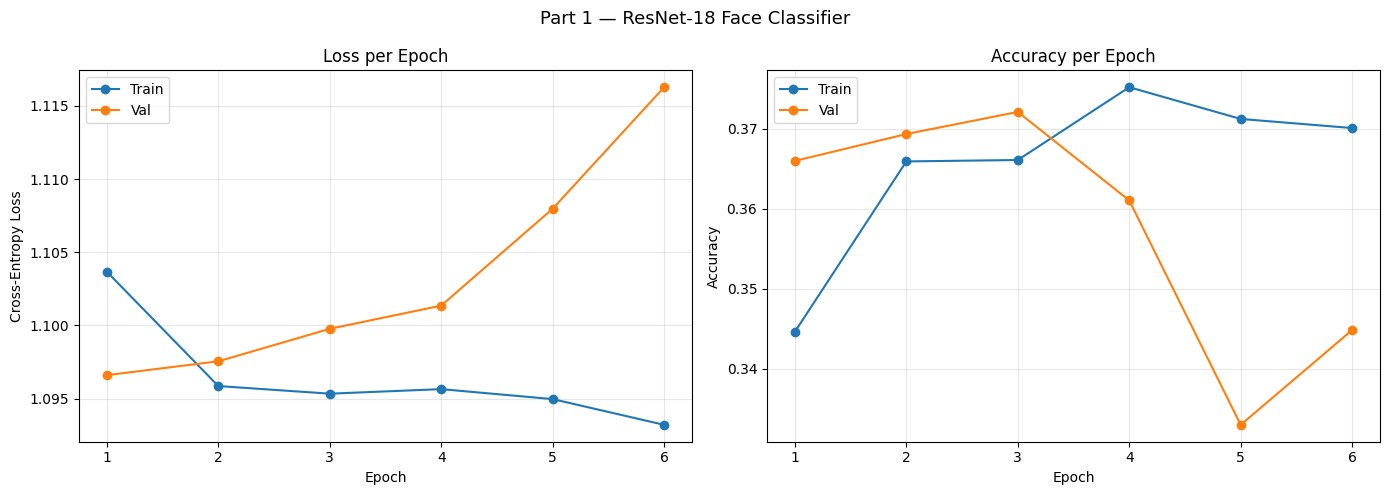

Saved to Drive.


In [11]:
# CELL 10 — Plot training curves

ep = range(1, len(history['train_loss']) + 1)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(ep, history['train_loss'], 'o-', label='Train')
ax1.plot(ep, history['val_loss'],   'o-', label='Val')
ax1.set_title('Loss per Epoch')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Cross-Entropy Loss')
ax1.legend(); ax1.grid(alpha=0.3)

ax2.plot(ep, history['train_acc'], 'o-', label='Train')
ax2.plot(ep, history['val_acc'],   'o-', label='Val')
ax2.set_title('Accuracy per Epoch')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.legend(); ax2.grid(alpha=0.3)

plt.suptitle('Part 1 — ResNet-18 Face Classifier', fontsize=13)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/training_curves_part1.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved to Drive.')

In [12]:
# CELL 11 — Test set evaluation

model.load_state_dict(torch.load(BEST_MODEL, map_location=device))
model.eval()
print('Best model loaded from Drive.')

test_loss, test_acc, test_preds, test_labels = evaluate(
    model, test_loader, criterion, aggregate_faces=True
)

macro_f1    = f1_score(test_labels, test_preds, average='macro')
weighted_f1 = f1_score(test_labels, test_preds, average='weighted')

print('=' * 52)
print('TEST RESULTS — Part 1 Original Face Model')
print('=' * 52)
print(f'Accuracy        : {test_acc:.4f}  ({test_acc*100:.2f}%)')
print(f'Macro F1        : {macro_f1:.4f}')
print(f'Weighted F1     : {weighted_f1:.4f}')
print()
print(classification_report(
    test_labels, test_preds,
    target_names=[LABEL_MAP[i] for i in range(NUM_CLASSES)]
))

Best model loaded from Drive.
TEST RESULTS — Part 1 Original Face Model
Accuracy        : 0.3471  (34.71%)
Macro F1        : 0.2736
Weighted F1     : 0.2895

              precision    recall  f1-score   support

     Neutral       0.26      0.56      0.36      1298
    Negative       0.45      0.48      0.46      2163
    Positive       0.00      0.00      0.00      1606

    accuracy                           0.35      5067
   macro avg       0.24      0.35      0.27      5067
weighted avg       0.26      0.35      0.29      5067



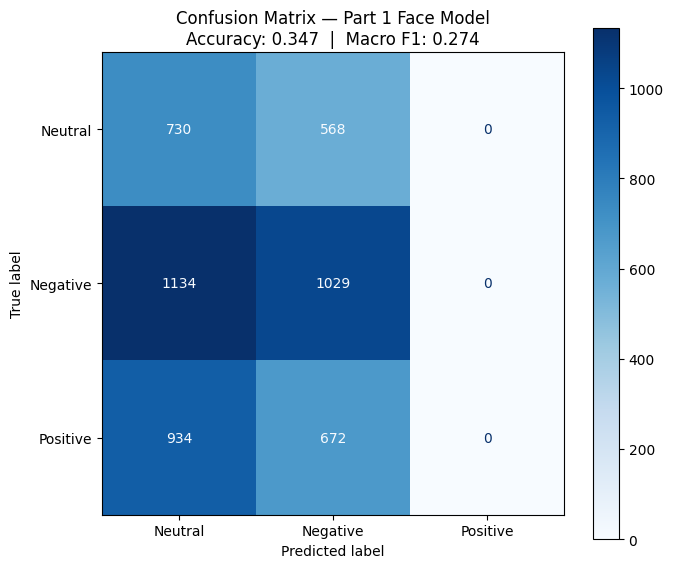

Saved to Drive.


In [13]:
# CELL 12 — Confusion matrix

cm = confusion_matrix(test_labels, test_preds)
class_names = [LABEL_MAP[i] for i in range(NUM_CLASSES)]

fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay(cm, display_labels=class_names).plot(
    ax=ax, colorbar=True, cmap='Blues'
)
ax.set_title(
    f'Confusion Matrix — Part 1 Face Model\n'
    f'Accuracy: {test_acc:.3f}  |  Macro F1: {macro_f1:.3f}',
    fontsize=12
)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/confusion_matrix_part1.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved to Drive.')

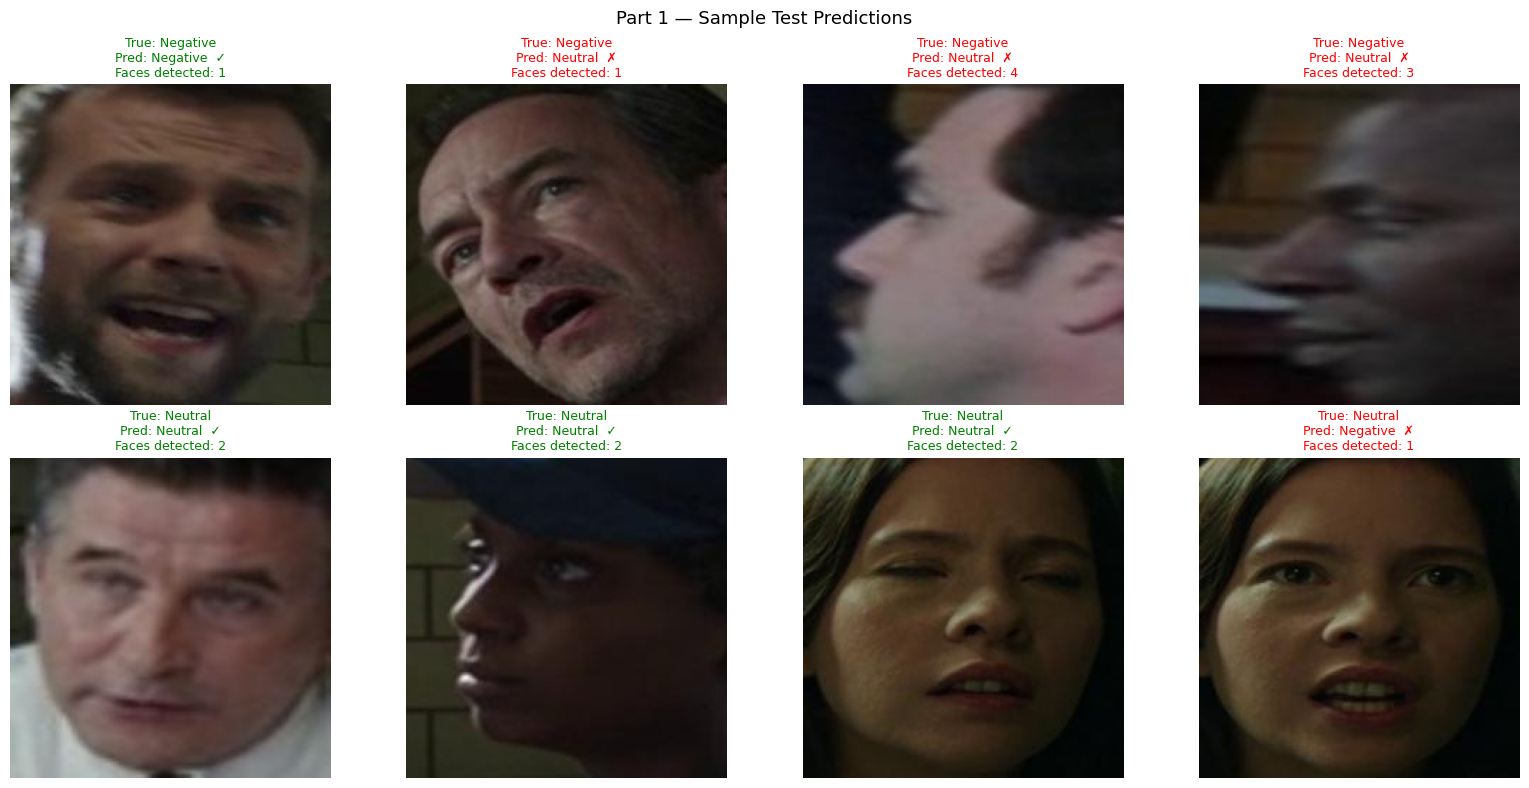

Saved to Drive.


In [14]:
# CELL 13 — Visualise sample predictions
# Shows 8 test images: green title = correct prediction, red = wrong.

with open(LABEL_TEST) as f:
    test_labels_all = [int(l.strip()) for l in f if l.strip()]

@torch.no_grad()
def predict_image(img_filename, face_map, face_dir):
    crops, tensors = [], []
    for crop_name in face_map[img_filename]:
        img = Image.open(os.path.join(face_dir, crop_name)).convert('RGB')
        crops.append(img)
        tensors.append(eval_tf(img))
    batch  = torch.stack(tensors).to(device)
    logits = model(batch)
    probs  = torch.softmax(logits, dim=1).mean(0)   # average over all faces
    return probs.cpu().numpy(), probs.argmax().item(), crops


sample_keys = list(test_face_map.keys())[:8]
fig, axes   = plt.subplots(2, 4, figsize=(16, 8))

for ax, fname in zip(axes.flatten(), sample_keys):
    img_idx    = int(fname.split('.')[0])
    true_label = test_labels_all[img_idx]
    probs, pred, crops = predict_image(fname, test_face_map, MULTI_TEST)

    ax.imshow(crops[0])
    ok = (pred == true_label)
    ax.set_title(
        f'True: {LABEL_MAP[true_label]}\nPred: {LABEL_MAP[pred]}  {chr(10003) if ok else chr(10007)}\n'
        f'Faces detected: {len(crops)}',
        color='green' if ok else 'red', fontsize=9
    )
    ax.axis('off')

plt.suptitle('Part 1 — Sample Test Predictions', fontsize=13)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/sample_predictions_part1.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved to Drive.')

In [15]:
# CELL 14 — Final summary

print('=' * 52)
print('PART 1 — FACE MODEL — FINAL RESULTS')
print('=' * 52)
print(f'  Model        : ResNet-18 (fine-tuned)')
print(f'  Detector     : MTCNN  keep_all=True')
print(f'  Multi-face   : average softmax probs across crops')
print(f'  No-face      : resized original image (fallback)')
print()
print(f'  Accuracy     : {test_acc:.4f}')
print(f'  Macro F1     : {macro_f1:.4f}')
print(f'  Weighted F1  : {weighted_f1:.4f}')
print()
print('Files saved to Drive:')
print('  best_face_model.pth          <- needed for Part 4 fusion')
print('  training_curves_part1.png    <- include in your report')
print('  confusion_matrix_part1.png   <- include in your report')
print('  sample_predictions_part1.png <- include in your report')
print('  train/dev/test_face_map.json <- needed for Part 4')

PART 1 — FACE MODEL — FINAL RESULTS
  Model        : ResNet-18 (fine-tuned)
  Detector     : MTCNN  keep_all=True
  Multi-face   : average softmax probs across crops
  No-face      : resized original image (fallback)

  Accuracy     : 0.3471
  Macro F1     : 0.2736
  Weighted F1  : 0.2895

Files saved to Drive:
  best_face_model.pth          <- needed for Part 4 fusion
  training_curves_part1.png    <- include in your report
  confusion_matrix_part1.png   <- include in your report
  sample_predictions_part1.png <- include in your report
  train/dev/test_face_map.json <- needed for Part 4
